In [2]:
!pip3 install librosa soundfile
!pip3 install torch torchvision torchaudio
!pip3 install openai-whisper transformers sentencepiece
!pip3 install scikit-learn pandas matplotlib seaborn tqdm
!pip3 install opencv-python
!pip install tensorflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 803.2/803.2 kB 18.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for openai-whisper: filename=openai_whisper-20250625-py3-none-any.whl size=803979 sha256=fbc550dd3a308be817d9726e60b17335b40f9c7bcc4e2c29d7d0bbfcf36285b1
  Stored in directory: /root/.cache/pip/wheels/61/d2/20/09ec9bef734d126cba375b15898010b6cc28578d8afdde5869
Successfully built openai-whisper


In [3]:
import os
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import cv2

from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    BatchNormalization,
    Dense,
    Dropout,
    Flatten
)

from tensorflow.keras.optimizers import Adam

from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report

import whisper

In [6]:
from typing_extensions import dataclass_transform
!pip3 install kagglehub
import kagglehub

data = kagglehub.dataset_download("uwrfkaggler/ravdess-emotional-speech-audio")

print("Path to dataset files:", data)


Using Colab cache for faster access to the 'ravdess-emotional-speech-audio' dataset.
Path to dataset files: /kaggle/input/ravdess-emotional-speech-audio


In [7]:
emotion_map = {
    "01": "neutral",
    "02": "calm",
    "03": "happy",
    "04": "sad",
    "05": "angry",
    "06": "fearful",
    "07": "disgust",
    "08": "surprised"
}



paths = []
labels = []

for f in os.listdir(data):
    p = os.path.join(data,f)
    if not os.path.isdir(p):
        continue
    for file in os.listdir(p):
        if file.endswith(".wav"):
            fp = os.path.join(p,file)
            code = file.split("-")[2]
            emotion = emotion_map[code]
            paths.append(fp)
            labels.append(emotion)

df = pd.DataFrame({"path" : paths,"emotion" : labels})
print("Total Samples",len(df))


Total Samples 1440


['angry' 'calm' 'disgust' 'fearful' 'happy' 'neutral' 'sad' 'surprised']


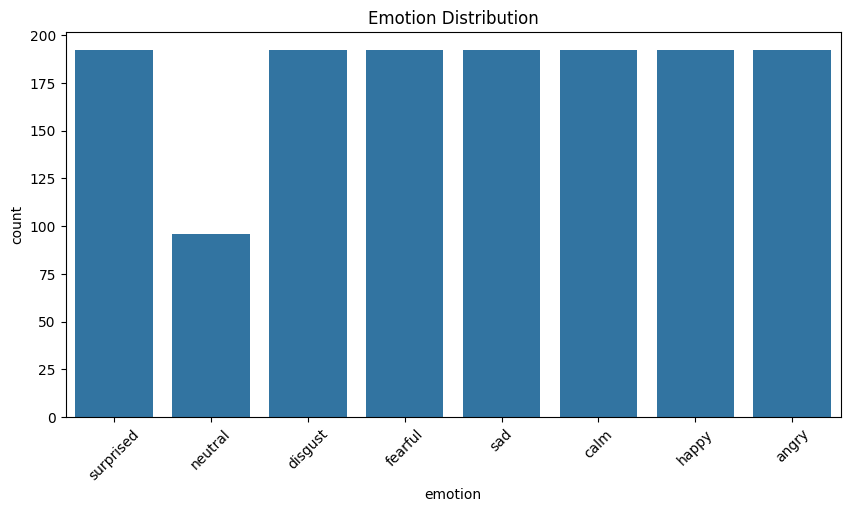

In [8]:

label_encoder = LabelEncoder()
df["label"] = label_encoder.fit_transform(df["emotion"])
print(label_encoder.classes_)

plt.figure(figsize=(10,5))
sns.countplot(x=df["emotion"])
plt.title("Emotion Distribution")
plt.xticks(rotation=45)
plt.show()


In [9]:
SampleRate = 22050
dur = 3
spertrack = SampleRate*dur
N = 128
img = 128

def preprocess_audio(file_path):
    signal, sr = librosa.load(
        file_path,
        sr=SampleRate,
        duration=dur
    )
    # Remove silence
    signal, _ = librosa.effects.trim(signal)
    # Pad if audio is too short
    if len(signal) < spertrack:

        padding = spertrack - len(signal)

        signal = np.pad(signal, (0, padding), mode='constant')
    else:
        signal = signal[:spertrack]

    # Normalize audio
    signal = librosa.util.normalize(signal)

    return signal

In [10]:
def create_mel_spectrogram(signal):

    mel_spec = librosa.feature.melspectrogram(
        y=signal,
        sr=SampleRate,
        n_mels=N
    )

    # Convert power spectrogram to decibel scale
    mel_spec_db = librosa.power_to_db(
        mel_spec,
        ref=np.max
    )

    return mel_spec_db

In [11]:
def resize_spectrogram(spec, size= img):

    resized_spec = cv2.resize(spec, (size, size))

    return resized_spec

In [12]:
x_audio = []
y_audio = []

for index,row in tqdm(df.iterrows(), total=len(df)):
  filepath = row["path"]
  emotion = row["emotion"]
  try:
    signal = preprocess_audio(filepath)
    mel_spec = create_mel_spectrogram(signal)
    mel_spec = resize_spectrogram(mel_spec)
    x_audio.append(mel_spec)
    y_audio.append(emotion)
  except Exception as e:
    print(f"Error processing {filepath}")
    print(e)

x_audio = np.array(x_audio)
y_audio = np.array(y_audio)

print(x_audio.shape)
print(y_audio.shape)

100%|██████████| 1440/1440 [00:56<00:00, 25.59it/s]


(1440, 128, 128)
(1440,)


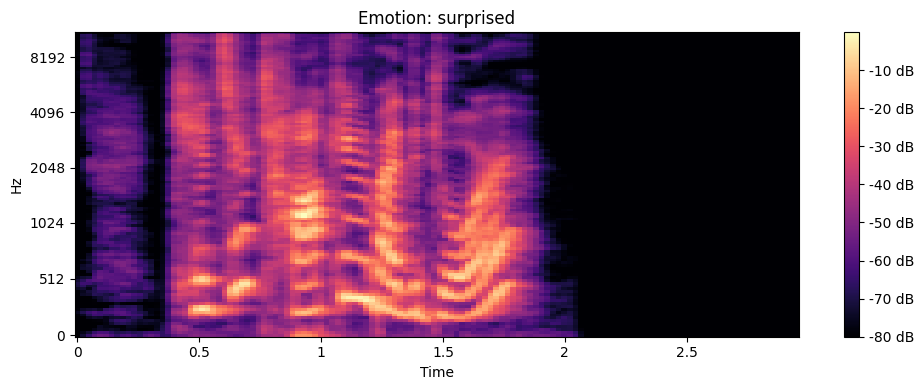

In [13]:
#visualising a spectogram

plt.figure(figsize=(10,4))
librosa.display.specshow(
    x_audio[0],
    sr=SampleRate,
    x_axis='time',
    y_axis='mel'
)
plt.colorbar(format='%+2.0f dB')
plt.title(f"Emotion: {y_audio[0]}")
plt.tight_layout()
plt.show()

In [14]:
x_audio = np.squeeze(x_audio)
print(x_audio.shape)

x_audio = x_audio[..., np.newaxis]

print(x_audio.shape)

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_audio)
y_categorical = to_categorical(y_encoded)
print(y_categorical.shape)

(1440, 128, 128)
(1440, 128, 128, 1)
(1440, 8)


In [15]:
X_train_audio, X_test_audio, y_train_audio, y_test_audio = train_test_split(
    x_audio,
    y_categorical,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Training Data:", X_train_audio.shape)
print("Testing Data:", X_test_audio.shape)

print("Training Labels:", y_train_audio.shape)
print("Testing Labels:", y_test_audio.shape)

Training Data: (1152, 128, 128, 1)
Testing Data: (288, 128, 128, 1)
Training Labels: (1152, 8)
Testing Labels: (288, 8)


In [16]:
audio = Sequential()

audio.add(Conv2D(32,(3,3),activation='relu',input_shape=(img,img,1)))
audio.add(BatchNormalization())
audio.add(MaxPooling2D((2,2)))
audio.add(Dropout(0.25))

audio.add(Conv2D(64,(3,3),activation='relu'))
audio.add(BatchNormalization())
audio.add(MaxPooling2D((2,2)))
audio.add(Dropout(0.25))

audio.add(Conv2D(128,(3,3),activation='relu'))
audio.add(BatchNormalization())
audio.add(MaxPooling2D((2,2)))
audio.add(Dropout(0.25))

audio.add(Flatten())
audio.add(Dense(256,activation='relu'))
audio.add(Dropout(0.4))

audio.add(Dense(128, activation='relu', name='audio_bottleneck'))

audio.add(Dense(8, activation='softmax'))

audio.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ audio_bottleneck (Dense)        │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,550,280 (24.99 MB)

 Trainable params: 6,549,832 (24.99 MB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/40
29/29 ━━━━━━━━━━━━━━━━━━━━ 21s 328ms/step - accuracy: 0.1846 - loss: 2.6917 - val_accuracy: 0.1126 - val_loss: 2.6263
Epoch 2/40
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.2628 - loss: 2.0103 - val_accuracy: 0.1342 - val_loss: 2.1724
Epoch 3/40
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.3040 - loss: 1.8761 - val_accuracy: 0.1948 - val_loss: 2.0744
Epoch 4/40
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.3279 - loss: 1.7889 - val_accuracy: 0.1948 - val_loss: 2.0143
Epoch 5/40
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.3561 - loss: 1.7614 - val_accuracy: 0.2251 - val_loss: 1.9347
Epoch 6/40
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.3833 - loss: 1.6420 - val_accuracy: 0.2857 - val_loss: 1.9116
Epoch 7/40
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.3974 - loss: 1.5972 - val_accuracy: 0.2944 - val_loss: 1.9067
Epoch 8/40
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.4104 - loss: 1.5506 - val_accuracy: 0.2814 -

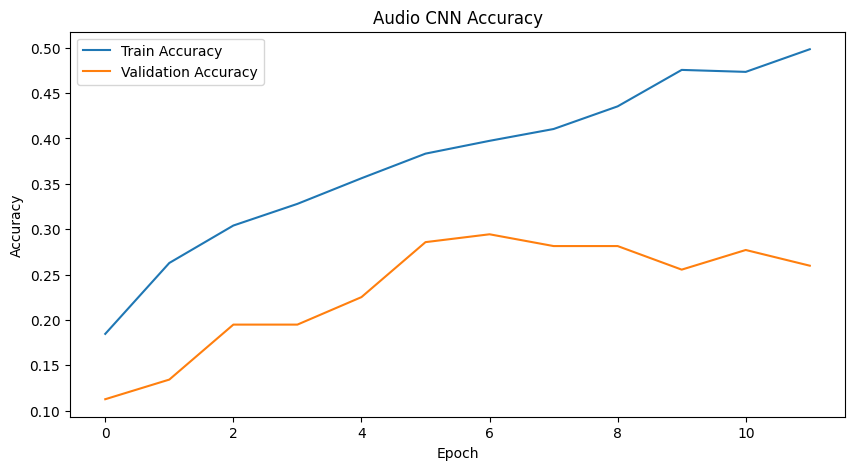

In [17]:
audio.compile(optimizer=Adam(learning_rate=0.0001),loss='categorical_crossentropy',metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss',patience=5,restore_best_weights=True)

#training
history_audio = audio.fit(
    X_train_audio,
    y_train_audio,
    validation_split=0.2,
    epochs=40,
    batch_size=32,
    callbacks=[early_stop]
)

#plot of accuracy curves

plt.figure(figsize=(10,5))
plt.plot(history_audio.history['accuracy'], label='Train Accuracy')
plt.plot(history_audio.history['val_accuracy'], label='Validation Accuracy')
plt.title("Audio CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


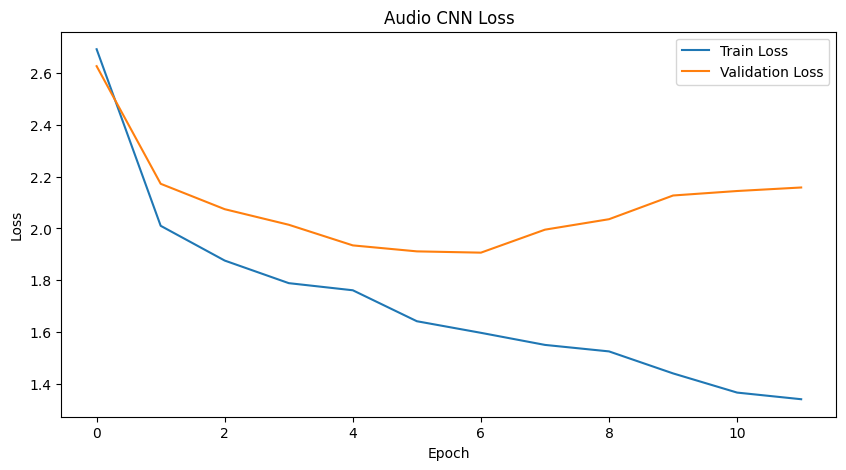

In [18]:
#loss curve
plt.figure(figsize=(10,5))
plt.plot(history_audio.history['loss'], label='Train Loss')
plt.plot(history_audio.history['val_loss'], label='Validation Loss')
plt.title("Audio CNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [19]:
test_loss, test_accuracy = audio.evaluate(
    X_test_audio,
    y_test_audio
)

print("Test Accuracy:", test_accuracy)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.2743 - loss: 1.9857
Test Accuracy: 0.2743055522441864


In [20]:
y_pred_probs = audio.predict(X_test_audio)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test_audio, axis=1)


print(
    classification_report(
        y_true,
        y_pred,
        target_names=label_encoder.classes_
    )
)

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
              precision    recall  f1-score   support

       angry       1.00      0.03      0.05        38
        calm       0.31      0.87      0.45        38
     disgust       1.00      0.05      0.10        38
     fearful       0.25      0.08      0.12        39
       happy       0.33      0.15      0.21        39
     neutral       0.16      0.32      0.21        19
         sad       0.17      0.26      0.21        38
   surprised       0.36      0.46      0.40        39

    accuracy                           0.27       288
   macro avg       0.45      0.28      0.22       288
weighted avg       0.46      0.27      0.22       288



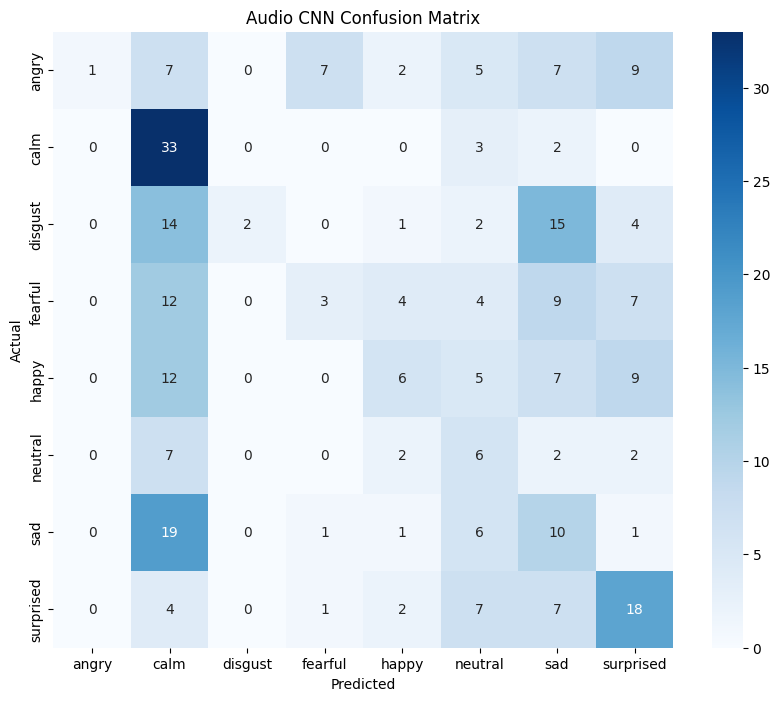

In [21]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Audio CNN Confusion Matrix")

plt.show()

In [22]:
whisper_model = whisper.load_model("tiny")

transcripts = []
for path in tqdm(df['path']):
    try:
        result = whisper_model.transcribe(path)
        text = result["text"]
        transcripts.append(text)

    except Exception as e:
        print(f"Error in {path}")
        transcripts.append("")

100%|█████████████████████████████████████| 72.1M/72.1M [00:01<00:00, 52.9MiB/s]
100%|██████████| 1440/1440 [05:42<00:00,  4.21it/s]


In [23]:
df['transcript'] = transcripts
df.head()

,path,emotion,label,transcript
0,/kaggle/input/ravdess-emotional-speech-audio/A...,surprised,7,"Kids, you're talking by the door?"
1,/kaggle/input/ravdess-emotional-speech-audio/A...,neutral,5,Kids are talking by the door.
2,/kaggle/input/ravdess-emotional-speech-audio/A...,disgust,2,Kids are talking by the door.
3,/kaggle/input/ravdess-emotional-speech-audio/A...,disgust,2,Kids are talking by the door.
4,/kaggle/input/ravdess-emotional-speech-audio/A...,neutral,5,Dogs are sitting by the door.


In [25]:
def clean_text(text):
    text = text.lower()
    text = text.strip()
    return text

df['clean_text'] = df['transcript'].apply(clean_text)

#Tokenisation
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

K = 5000
tokenizer = Tokenizer(num_words=K)
tokenizer.fit_on_texts(df['clean_text'])
text_sequences = tokenizer.texts_to_sequences(df['clean_text'])

#padding
l = 20

X_text = pad_sequences(
    text_sequences,
    maxlen= l,
    padding='post'
)

y_text = y_categorical

X_train_text, X_test_text, y_train_text, y_test_text = train_test_split(
    X_text,
    y_text,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print(X_train_text.shape)
print(X_test_text.shape)


(1152, 20)
(288, 20)


In [26]:
vocab_size = len(tokenizer.word_index) + 1
print("Vocabulary Size:", vocab_size)

Vocabulary Size: 147


In [28]:
from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Embedding,
    GRU,
    Dense,
    Dropout,
    Bidirectional
)

from tensorflow.keras.optimizers import Adam

from tensorflow.keras.callbacks import EarlyStopping

In [30]:
EMBEDDING_DIM = 128

MAX_LEN = 20

gru = Sequential()

# Embedding Layer
gru.add(Embedding(
        input_dim=vocab_size,
        output_dim=EMBEDDING_DIM,
        input_length=MAX_LEN ))

# Bidirectional GRU
gru.add(Bidirectional(GRU(64,return_sequences=False)))


gru.add(Dropout(0.4))
gru.add(Dense(64, activation='relu'))
gru.add(Dense(32, activation='relu', name='text_bottleneck'))
gru.add(Dense(8, activation='softmax'))

gru.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ text_bottleneck (Dense)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [31]:
gru.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stop_text = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history_text = gru.fit(
    X_train_text,
    y_train_text,
    validation_split=0.2,
    epochs=30,
    batch_size=32,
    callbacks=[early_stop_text]
)

Epoch 1/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - accuracy: 0.1227 - loss: 2.0772 - val_accuracy: 0.1255 - val_loss: 2.0683
Epoch 2/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.1238 - loss: 2.0694 - val_accuracy: 0.1126 - val_loss: 2.0642
Epoch 3/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.1488 - loss: 2.0653 - val_accuracy: 0.1169 - val_loss: 2.0631
Epoch 4/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.1498 - loss: 2.0658 - val_accuracy: 0.1126 - val_loss: 2.0613
Epoch 5/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.1303 - loss: 2.0638 - val_accuracy: 0.1299 - val_loss: 2.0605
Epoch 6/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.1694 - loss: 2.0615 - val_accuracy: 0.1255 - val_loss: 2.0569
Epoch 7/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.1694 - loss: 2.0599 - val_accuracy: 0.1255 - val_loss: 2.0581
Epoch 8/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.1629 - loss: 2.0509 - val_accuracy: 0.1299 - v

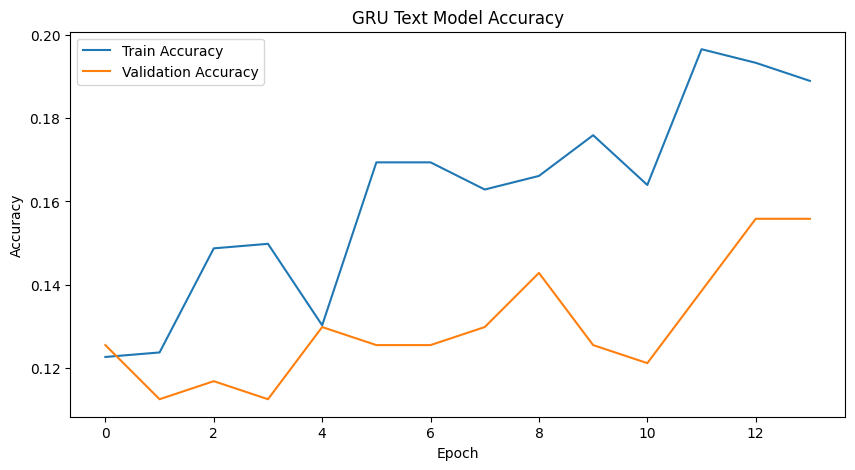

In [32]:
plt.figure(figsize=(10,5))
plt.plot(
    history_text.history['accuracy'],
    label='Train Accuracy')

plt.plot(
    history_text.history['val_accuracy'],
    label='Validation Accuracy')

plt.title("GRU Text Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

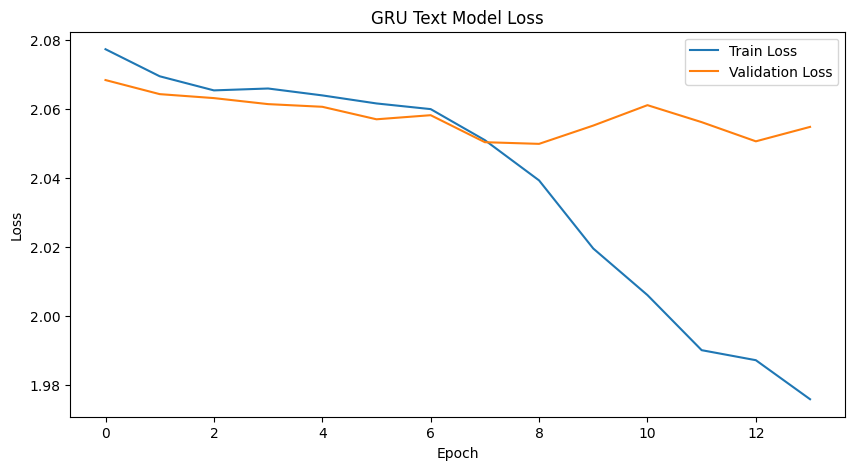

In [33]:
plt.figure(figsize=(10,5))
plt.plot(
    history_text.history['loss'],
    label='Train Loss')

plt.plot(
    history_text.history['val_loss'],
    label='Validation Loss')

plt.title("GRU Text Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [36]:
test_loss_text, test_acc_text = gru.evaluate(
    X_test_text,
    y_test_text
)

print("Text Model Accuracy:", test_acc_text)

y_pred_probs_text = gru.predict(X_test_text)
y_pred_text = np.argmax(y_pred_probs_text, axis=1)
y_true_text = np.argmax(y_test_text, axis=1)

print(
    classification_report(
        y_true_text,
        y_pred_text,
        target_names=label_encoder.classes_
    )
)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.1250 - loss: 2.0642 
Text Model Accuracy: 0.125
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step  
              precision    recall  f1-score   support

       angry       0.00      0.00      0.00        38
        calm       0.12      0.45      0.19        38
     disgust       0.00      0.00      0.00        38
     fearful       0.12      0.41      0.18        39
       happy       0.00      0.00      0.00        39
     neutral       0.00      0.00      0.00        19
         sad       0.20      0.08      0.11        38
   surprised       0.00      0.00      0.00        39

    accuracy                           0.12       288
   macro avg       0.06      0.12      0.06       288
weighted avg       0.06      0.12      0.07       288



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


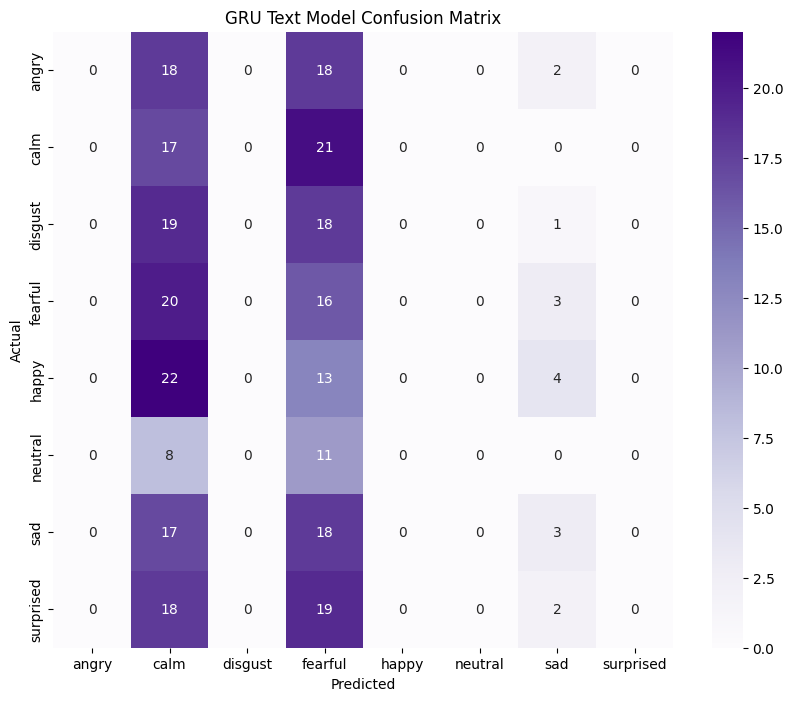

In [37]:

cm_text = confusion_matrix(
    y_true_text,
    y_pred_text)

plt.figure(figsize=(10,8))
sns.heatmap(
    cm_text,
    annot=True,
    fmt='d',
    cmap='Purples',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("GRU Text Model Confusion Matrix")
plt.show()

In [39]:
audio_probs = audio.predict(X_test_audio)
text_probs = gru.predict(X_test_text)
avg_probs = (audio_probs + text_probs) / 2

avg_predictions = np.argmax(avg_probs, axis=1)
y_true_fusion = np.argmax(y_test_audio, axis=1)

from sklearn.metrics import accuracy_score

avg_accuracy = accuracy_score(
    y_true_fusion,
    avg_predictions
)

print("Average Fusion Accuracy:", avg_accuracy)

from sklearn.metrics import classification_report

print(
    classification_report(
        y_true_fusion,
        avg_predictions,
        target_names=label_encoder.classes_
    )
)


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
Average Fusion Accuracy: 0.3020833333333333
              precision    recall  f1-score   support

       angry       1.00      0.03      0.05        38
        calm       0.27      0.89      0.42        38
     disgust       1.00      0.05      0.10        38
     fearful       0.29      0.13      0.18        39
       happy       0.36      0.21      0.26        39
     neutral       0.29      0.26      0.28        19
         sad       0.18      0.24      0.21        38
   surprised       0.42      0.59      0.49        39

    accuracy                           0.30       288
   macro avg       0.48      0.30      0.25       288
weighted avg       0.49      0.30      0.25       288



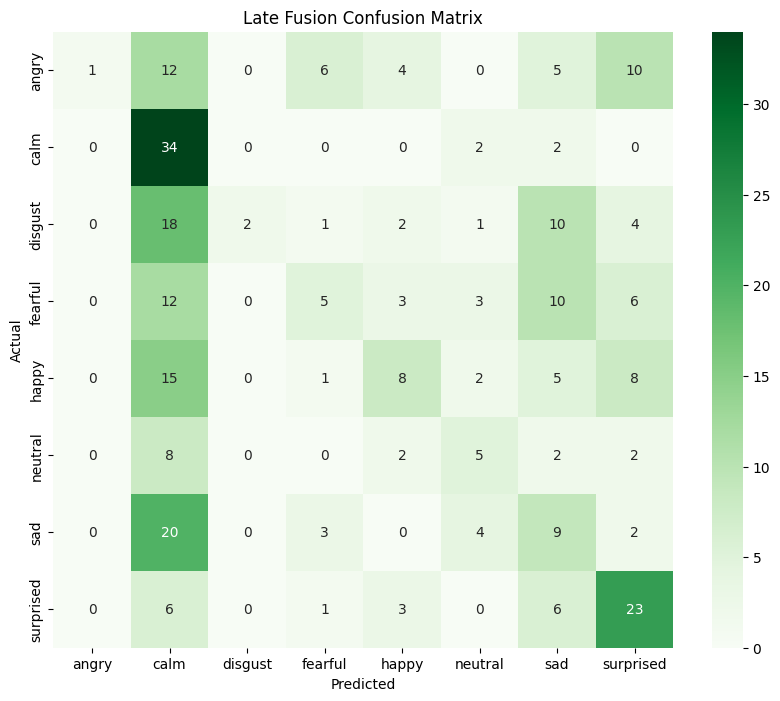

In [41]:


fusion_cm = confusion_matrix(
    y_true_fusion,
    avg_predictions
)

plt.figure(figsize=(10,8))

sns.heatmap(
    fusion_cm,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Late Fusion Confusion Matrix")

plt.show()